# Testing FCI with BN "ASIA" and comparing with GHC and MIIC

In [1]:
from IPython.display import clear_output
import pyagrum.lib.notebook as gnb
import FCI_callback as fci
import pyagrum as gum
from utils import make_bnlearner_ci, draw_pag
from IPython.display import clear_output, display
from IPython.display import display, HTML
import html

### Loading asia BN and computing Xi test

In [2]:
csv_path = "out/temp_database.csv"
bn = gum.loadBN("asia.bif")
sampler = gum.BNDatabaseGenerator(bn)
sampler.drawSamples(10000000)
df = sampler.to_pandas()
# run FCI
alpha = 0.05
test_name = "g2"
ci_test = make_bnlearner_ci(
    df,
    test_name,
    alpha,
)
X = list(df.columns)

### Visualization of FCI iterations

In [3]:
def viz_cb(C, label=""):
    clear_output(wait=True)
    dot = draw_pag(C, filename=label)  
    display(dot)

class PAGStepCollector:
    def __init__(self, max_frames=None, title="FCI steps"):
        self.frames = []
        self.max_frames = max_frames
        self.title = title
        self._i = 0

    def __call__(self, C, label=""):
        if self.max_frames is not None and len(self.frames) >= self.max_frames:
            return

        dot = draw_pag(C, filename=label) 

        svg_bytes = dot.pipe(format="svg")
        svg = svg_bytes.decode("utf-8")

        self.frames.append((f"{self._i:05d}  {label}", svg))
        self._i += 1

    def show_all(self, collapsed=True):
        parts = [f"<h3>{html.escape(self.title)} ({len(self.frames)} frames)</h3>"]

        for lbl, svg in self.frames:
            safe_lbl = html.escape(lbl)

            if collapsed:
                parts.append(f"""
<details style="margin:10px 0">
  <summary style="cursor:pointer; font-family:monospace">
    {safe_lbl}
  </summary>
  <div style="border:1px solid #ddd; padding:6px; margin-top:6px">
    {svg}
  </div>
</details>
""")
            else:
                parts.append(f"""
<div style="margin:16px 0">
  <div style="font-family:monospace; margin-bottom:6px">{safe_lbl}</div>
  <div style="border:1px solid #ddd; padding:6px">
    {svg}
  </div>
</div>
""")

        display(HTML("".join(parts)))

In [4]:
collector = PAGStepCollector(max_frames=None, title="FCI PAG evolution")

C, sepset = fci.fci(X, ci_test, alpha=alpha, callback=collector)

collector.show_all(collapsed=True)   

### FCI

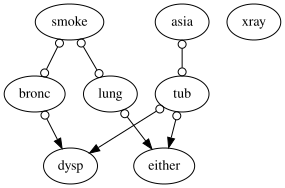

In [5]:
C, sepset = fci.fci(X, ci_test, alpha=alpha, callback=viz_cb)

### MIIC

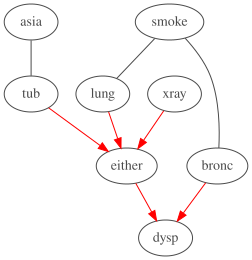

In [6]:
learner_miic = gum.BNLearner(csv_path)
learner_miic.useMIIC()
learner_miic.useNMLCorrection() 
eg_miic = learner_miic.learnEssentialGraph()
eg_miic
gnb.showDot(eg_miic.toDot())

### GHC

In [7]:
learner_ghc = gum.BNLearner(csv_path)
learner_ghc.useGreedyHillClimbing()

bn_ghc = learner_ghc.learnBN()
eg_ghc = gum.EssentialGraph(bn_ghc)
gnb.sideBySide(bn_ghc, eg_ghc)

### Evaluation

We first look at a side-by-side comparison of the 3 algorithms along different metrics.

We have already created the results dataset (takes a long time to generate), so the code below only aggregates the results and creates the plots.

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

def analyse_full(infile="results/results_full.csv", outfile="figures/algorithm_comparison.png"):
    results = pd.read_csv(infile)

    # 1. For each model, when is it able to find the true structure
    true_miic = results.loc[(results["equiv"]) & (results["algorithm"]=="MIIC"),
                            ["num_nodes", "ratio_fraction", "domain_size", "sample_size", "trial"]]
    print(f"MIIC was correct in {len(true_miic)} cases.")

    true_ghc = results.loc[(results["equiv"]) & (results["algorithm"]=="GHC"),
                            ["num_nodes", "ratio_fraction", "domain_size", "sample_size", "trial"]]
    print(f"GHC was correct in {len(true_ghc)} cases.")

    true_fci = results.loc[(results["equiv"]) & (results["algorithm"]=="FCI"),
                            ["num_nodes", "ratio_fraction", "domain_size", "sample_size", "trial"]]
    print(f"FCI was correct in {len(true_fci)} cases.")

    # 2. Make 6 plots (on the same figure, one for each metric) of the three models for:
    # - as num_nodes varies, best other parameters (ratio, domain, sample)
    # - etc. (all other possible combinations)
    metrics = ["time", "precision", "recall", "f1", "pure", "structural"]
    parameters = ["num_nodes", "ratio_fraction", "domain_size", "sample_size"]
    algorithms = ["MIIC", "GHC", "FCI"]
    
    fig, axes = plt.subplots(6, 4, figsize=(20, 20))
    fig.suptitle("Algorithm Performance Across Parameters", fontsize=16, y=0.995)
    
    colors = {"MIIC": "blue", "GHC": "green", "FCI": "red"}
    markers = {"MIIC": "o", "GHC": "s", "FCI": "^"}
    
    for row, metric in enumerate(metrics):
        for col, param in enumerate(parameters):
            ax = axes[row, col]
            
            # For each parameter, we want to vary it and keep others at their best values
            # We'll aggregate across trials and optimize over other parameters
            other_params = [p for p in parameters if p != param]
            
            for algo in algorithms:
                algo_data = results[results["algorithm"] == algo].copy()
                
                # Group by the parameter we're varying
                param_values = sorted(algo_data[param].unique())
                mean_values = []
                
                for val in param_values:
                    subset = algo_data[algo_data[param] == val]
                    
                    # For each value of this parameter, find the best combination of other parameters
                    # by taking the mean across trials and finding the ma
                    grouped = subset.groupby(other_params)[metric].mean()
                    
                    # Get all trials for the best parameter combination
                    best_params = grouped.idxmax()
                    if not isinstance(best_params, tuple):
                        best_params = (best_params,)
                    
                    # Filter to get all trials with these best parameters
                    mask = pd.Series(True, index=subset.index)
                    for i, other_param in enumerate(other_params):
                        mask &= (subset[other_param] == best_params[i])
                    
                    best_subset = subset[mask]
                    mean_values.append(best_subset[metric].mean())
                   
                # Plot with error bars
                ax.plot(param_values, mean_values, 
                        label=algo, color=colors[algo], marker=markers[algo],
                        linewidth=2, markersize=6)
            
            # Formatting
            ax.set_xlabel(param.replace("_", " ").title(), fontsize=10)
            if col == 0:
                ax.set_ylabel(metric.replace("_", " ").title(), fontsize=10)
            ax.grid(True, alpha=0.3)
            ax.legend(loc="best", fontsize=8)
            
            # Set appropriate y-limits based on metric
            if metric in ["precision", "recall", "f1"]:
                ax.set_ylim(-0.05, 1.05)
            
    plt.tight_layout()
    plt.show()

MIIC was correct in 0 cases.
GHC was correct in 0 cases.
FCI was correct in 0 cases.


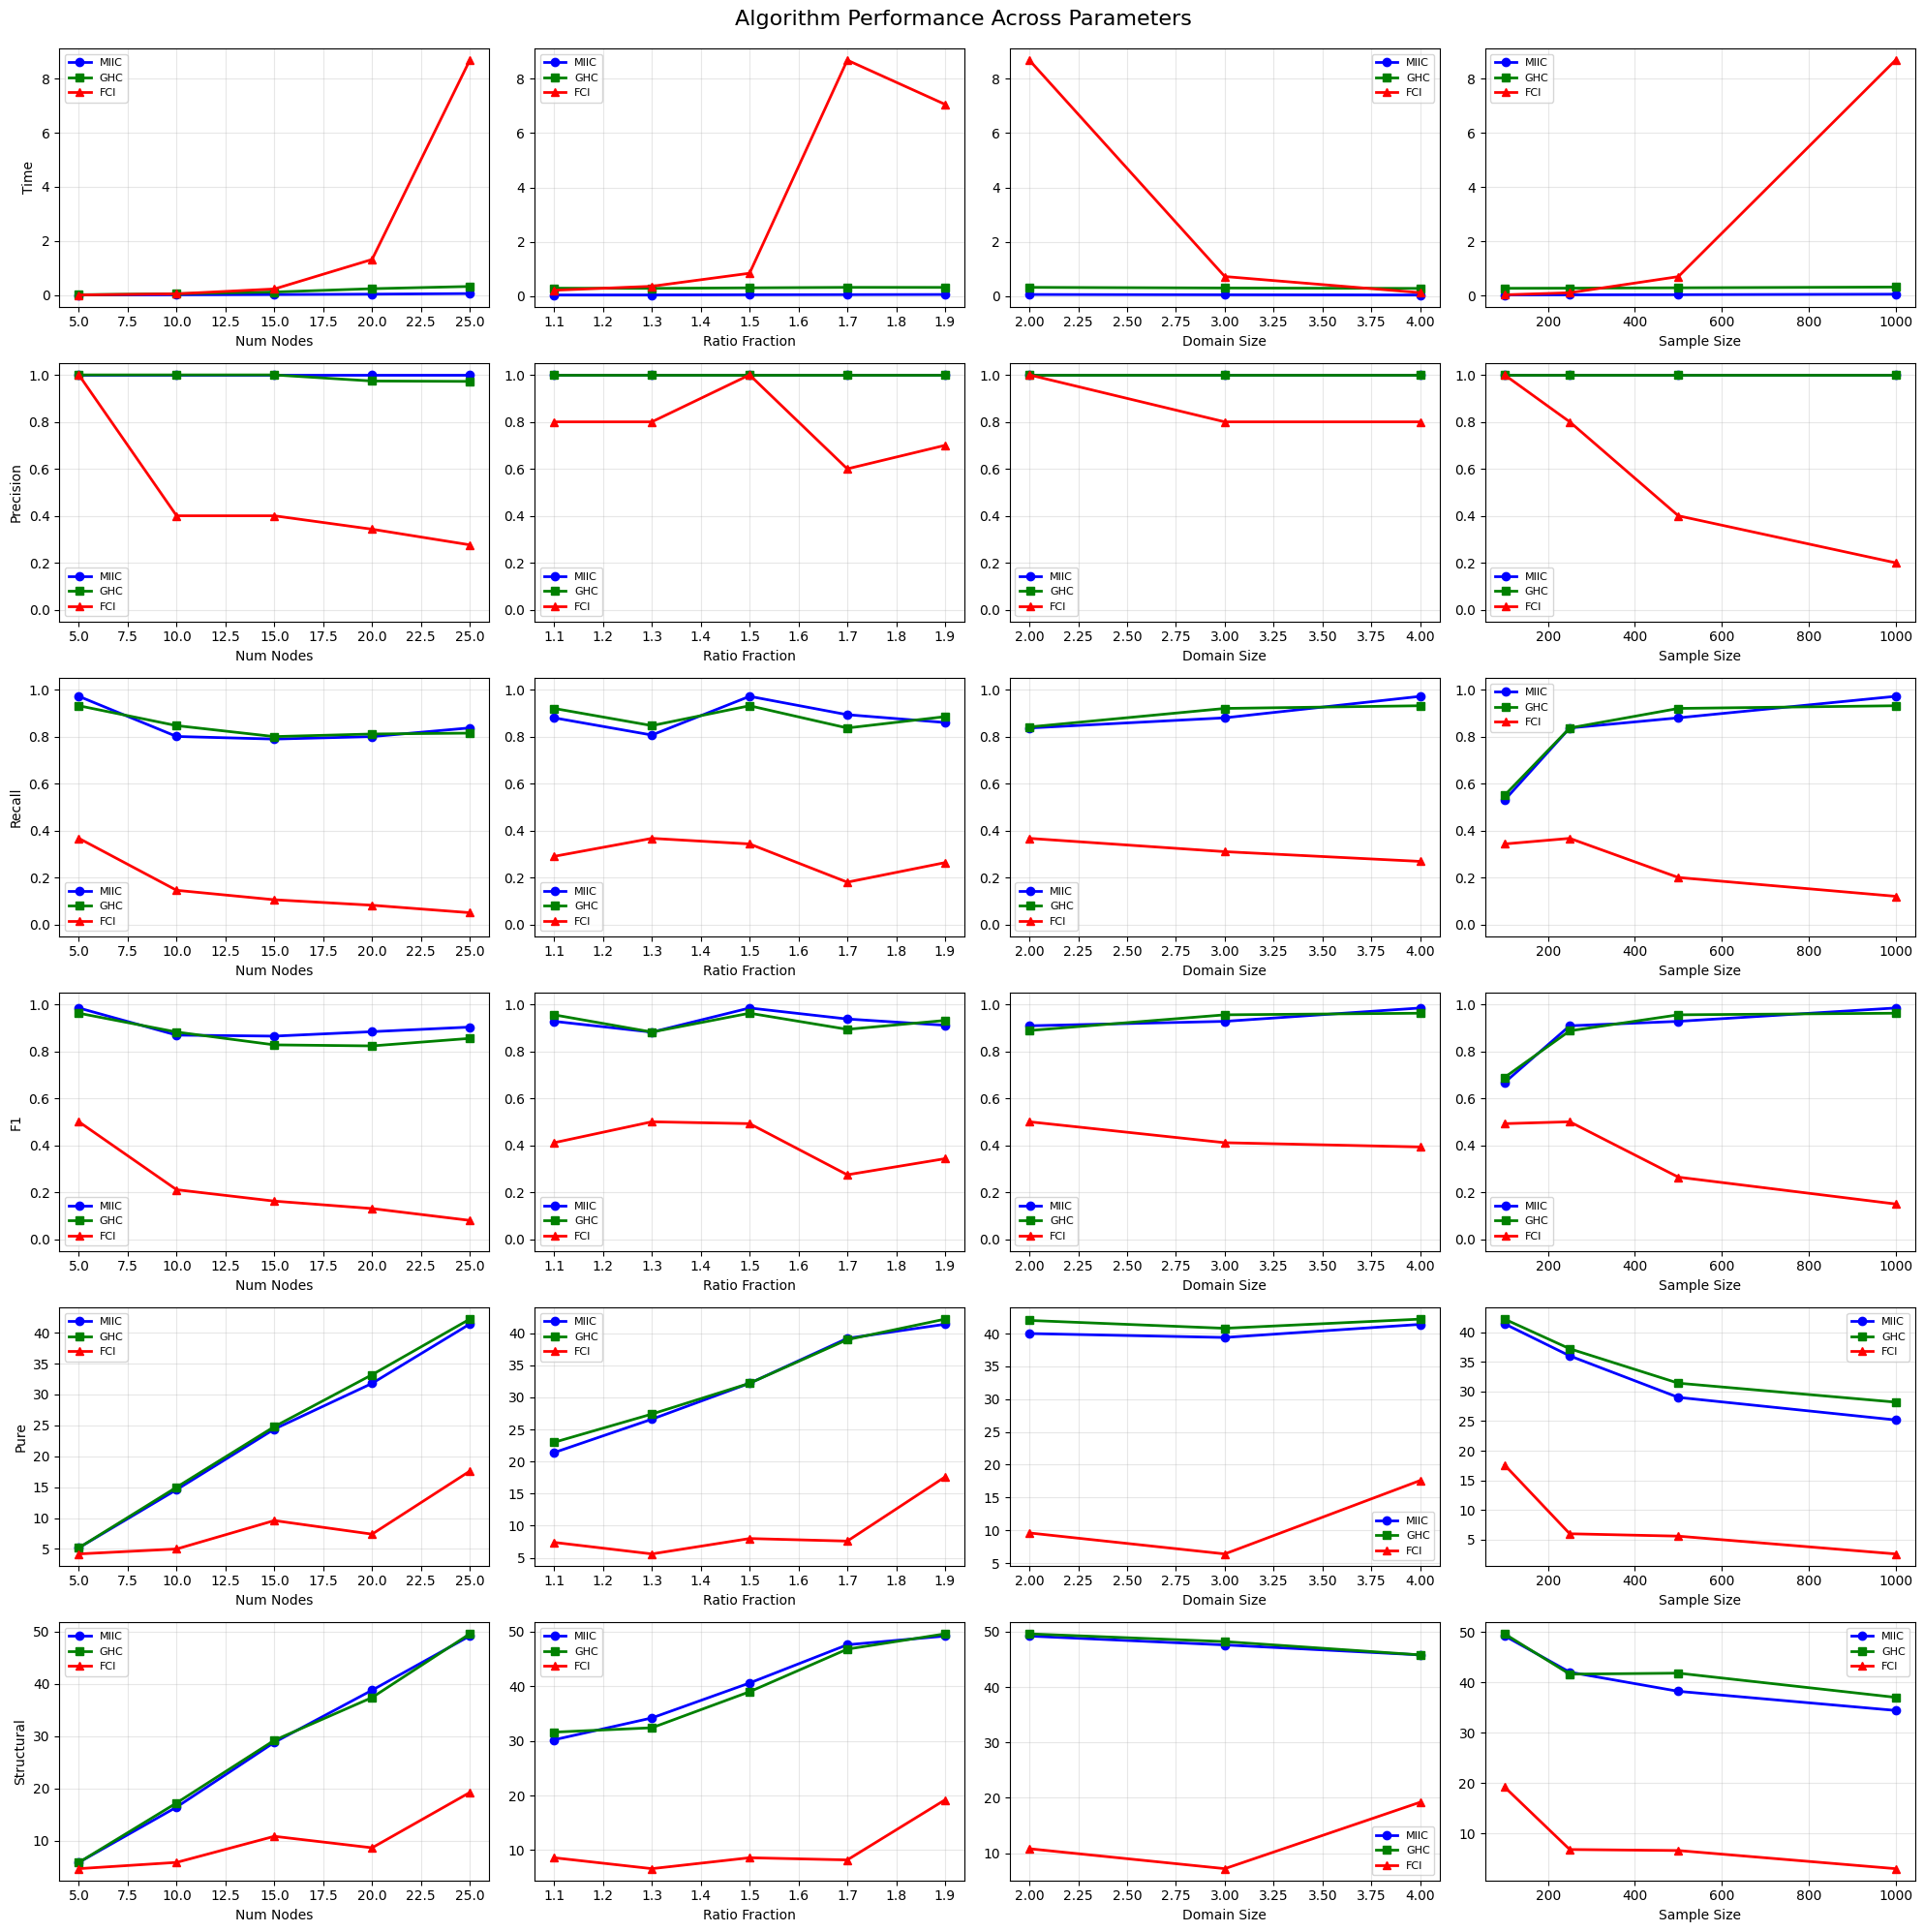

In [4]:
analyse_full()

The execution time plot for varying domain size looks strange for FCI. The code below aggregates all the results of FCI (so no longer only the best) and plots.

In [7]:
def fci_times():
    results = pd.read_csv("results/results_full.csv")
    res_fci = results[results["algorithm"]=="FCI"][["time", "domain_size"]]
    times = res_fci.groupby("domain_size").mean()
    
    plt.plot(times.index, times["time"], color="red", marker="^", linewidth=2, markersize=6)
    plt.xlabel("Domain Size")
    plt.ylabel("Time")
    plt.grid(True, alpha=0.3)
    plt.show()

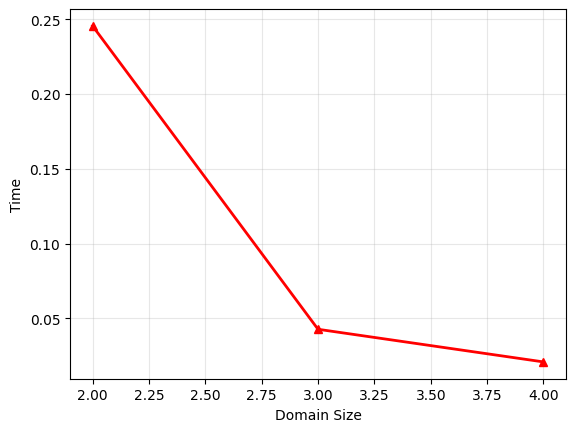

In [8]:
fci_times()

We can see then that there FCI is behaving weirdly.